Please upload: googleplaystore.csv


Saving googleplaystore.csv to googleplaystore.csv

Uploaded: googleplaystore.csv

First 5 Rows:
                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   
3                              Sketch - Draw & Paint  ART_AND_DESIGN     4.5   
4              Pixel Draw - Number Art Coloring Book  ART_AND_DESIGN     4.3   

  Reviews  Size     Installs  Type Price Content Rating  \
0     159   19M      10,000+  Free     0       Everyone   
1     967   14M     500,000+  Free     0       Everyone   
2   87510  8.7M   5,000,000+  Free     0       Everyone   
3  215644   25M  50,000,000+  Free     0           Teen   
4     967  2.8M     100,000+  Free     0       Everyone   

                      Genres      Last Updated         Current Ver  

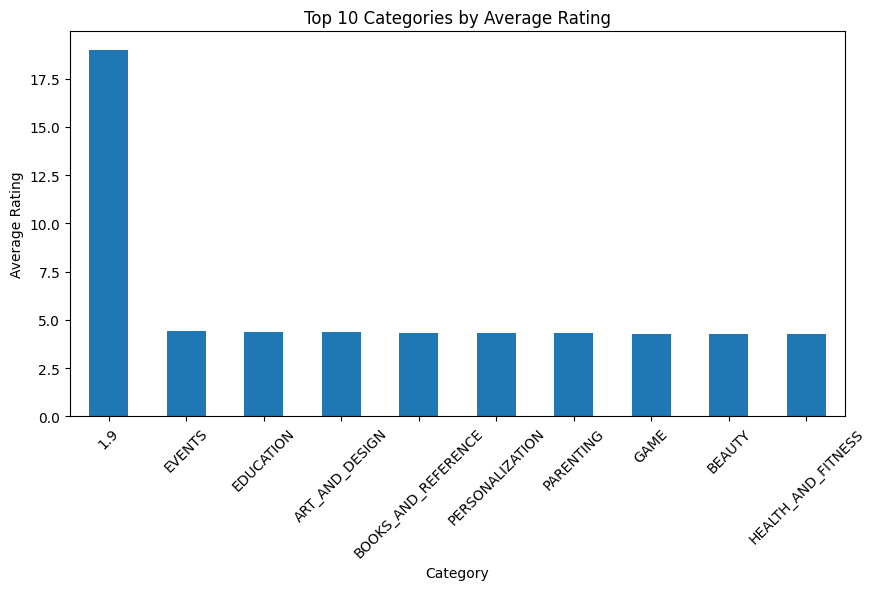


Top 10 Categories by Number of Apps:
Category
FAMILY             1972
GAME               1144
TOOLS               843
MEDICAL             463
BUSINESS            460
PRODUCTIVITY        424
PERSONALIZATION     392
COMMUNICATION       387
SPORTS              384
LIFESTYLE           382
Name: count, dtype: int64


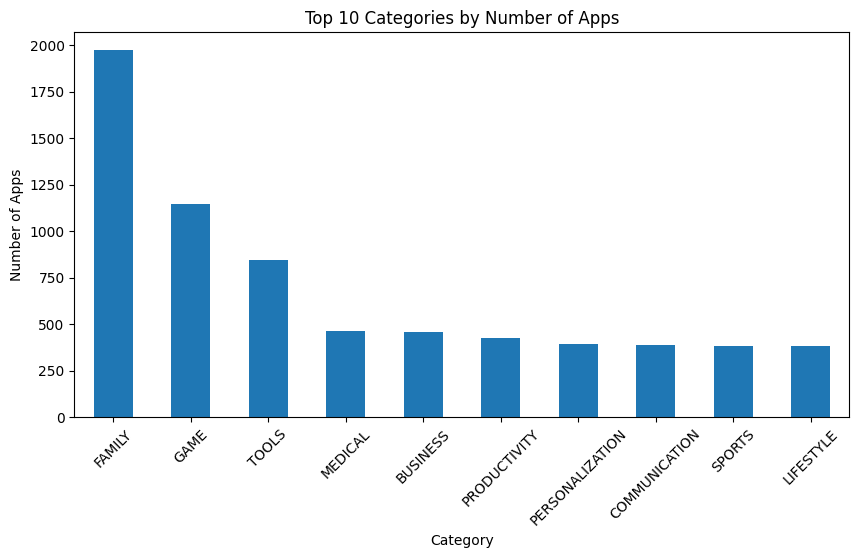


Free vs Paid Apps:
Type
Free    10039
Paid      800
0           1
Name: count, dtype: int64


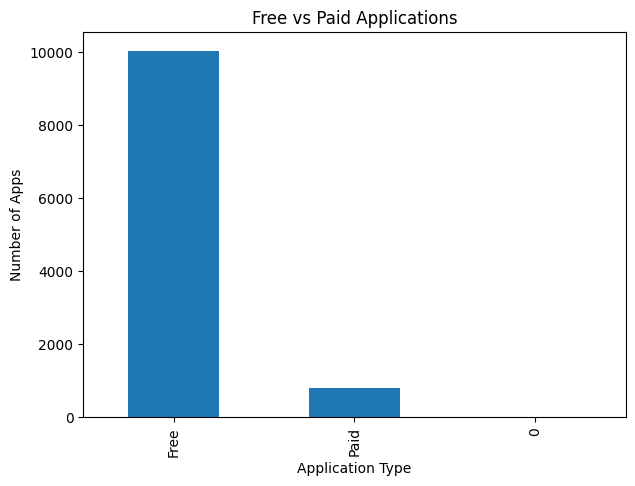


Correlation Matrix:
            Rating   Reviews  Installs     Price
Rating    1.000000  0.068141  0.051355 -0.021903
Reviews   0.068141  1.000000  0.643122 -0.009667
Installs  0.051355  0.643122  1.000000 -0.011689
Price    -0.021903 -0.009667 -0.011689  1.000000


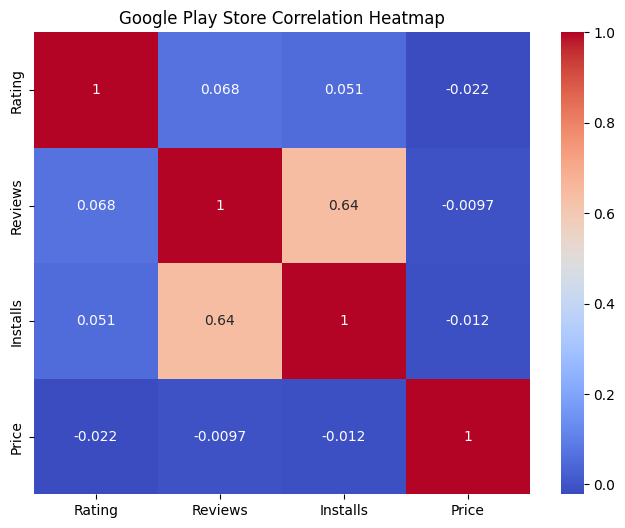

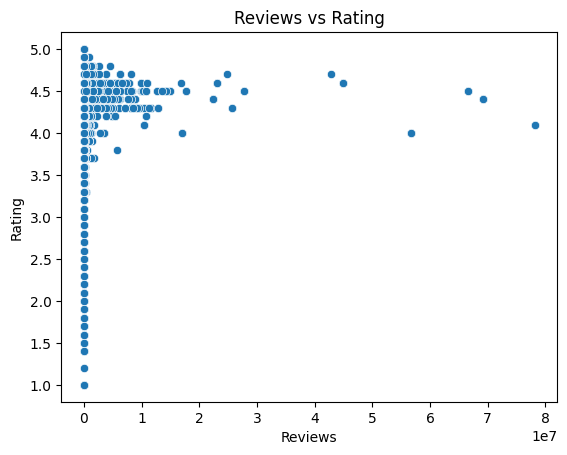

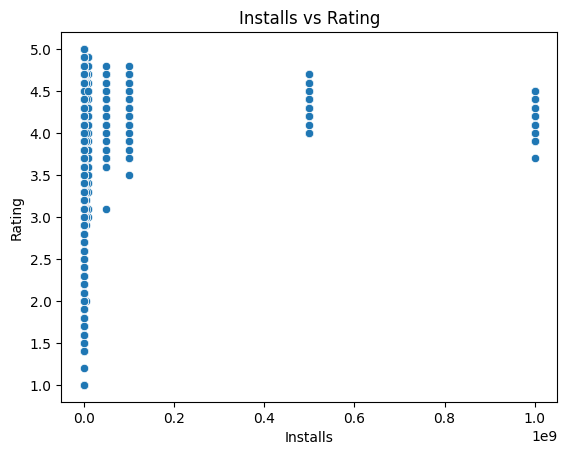

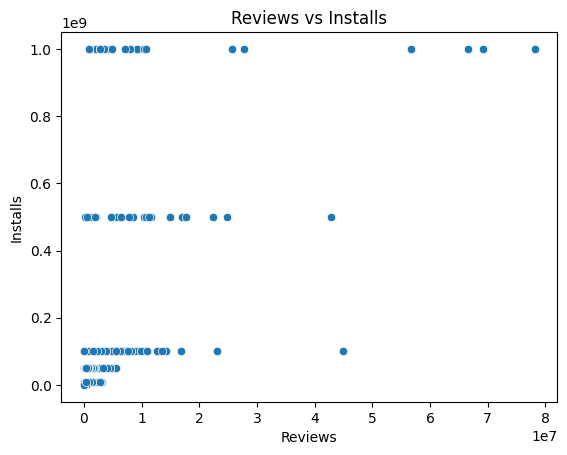

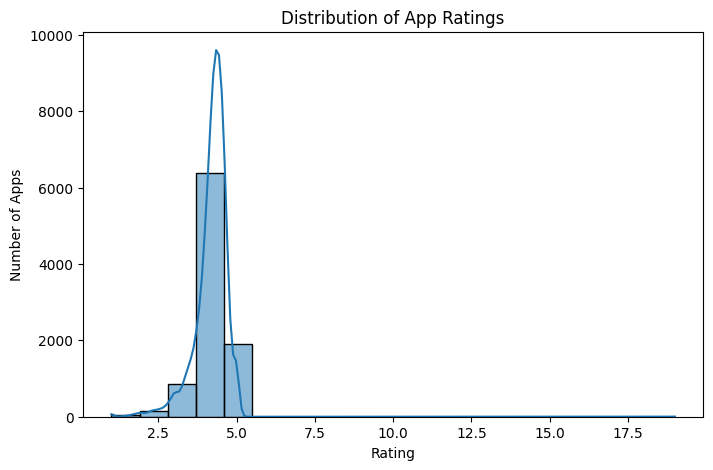


GOOGLE PLAY STORE EDA COMPLETED

Total Applications: 10841
Average Rating: 4.193338315362443
Total Categories: 34
Free Applications: 10039
Paid Applications: 800
Highest Rating: 19.0
Lowest Rating: 1.0


In [1]:
# ============================================================
# GOOGLE PLAY STORE ANALYSIS
# EXPLORATORY DATA ANALYSIS (EDA)
# SINGLE-RUN GOOGLE COLAB VERSION
# ============================================================

# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files


# ------------------------------------------------------------
# 2. Upload Dataset
# ------------------------------------------------------------

print("Please upload: googleplaystore.csv")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

print("\nUploaded:", filename)


# ------------------------------------------------------------
# 3. Read Dataset
# ------------------------------------------------------------

df = pd.read_csv(filename)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nData Types:")
print(df.dtypes)


# ------------------------------------------------------------
# 4. Descriptive Statistics
# ------------------------------------------------------------

print("\nDescriptive Statistics:")
print(df.describe(include="all"))


# ------------------------------------------------------------
# 5. Convert Numerical Columns
# ------------------------------------------------------------

df["Reviews"] = pd.to_numeric(
    df["Reviews"],
    errors="coerce"
)

df["Installs"] = pd.to_numeric(
    df["Installs"]
    .astype(str)
    .str.replace("+", "", regex=False)
    .str.replace(",", "", regex=False),
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False),
    errors="coerce"
)

df["Rating"] = pd.to_numeric(
    df["Rating"],
    errors="coerce"
)

print("\nNumerical conversion completed.")


# ------------------------------------------------------------
# 6. Missing Values
# ------------------------------------------------------------

print("\nMissing Values:")
print(df.isnull().sum())


# ------------------------------------------------------------
# 7. Highly Rated Apps
# ------------------------------------------------------------

high_rated = df[
    df["Rating"] >= 4.5
]

print("\nHighly Rated Apps:")
print(high_rated.head())


# ------------------------------------------------------------
# 8. Free Apps
# ------------------------------------------------------------

free_apps = df[
    df["Type"] == "Free"
]

print("\nFree Apps:")
print(free_apps.head())


# ------------------------------------------------------------
# 9. Paid Apps
# ------------------------------------------------------------

paid_apps = df[
    df["Type"] == "Paid"
]

print("\nPaid Apps:")
print(paid_apps.head())


# ------------------------------------------------------------
# 10. Most Reviewed Apps
# ------------------------------------------------------------

sorted_df = df.sort_values(
    by="Reviews",
    ascending=False
)

print("\nMost Reviewed Apps:")
print(
    sorted_df[
        [
            "App",
            "Reviews",
            "Rating",
            "Installs"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 11. Most Installed Apps
# ------------------------------------------------------------

installed_df = df.sort_values(
    by="Installs",
    ascending=False
)

print("\nMost Installed Apps:")

print(
    installed_df[
        [
            "App",
            "Installs",
            "Rating"
        ]
    ].head(10)
)


# ------------------------------------------------------------
# 12. Mean, Median, Mode and Standard Deviation
# ------------------------------------------------------------

print("\nRating Statistics")

print(
    "Mean :",
    df["Rating"].mean()
)

print(
    "Median :",
    df["Rating"].median()
)

print("Mode :")

print(
    df["Rating"].mode()
)

print(
    "Standard Deviation :",
    df["Rating"].std()
)


# ------------------------------------------------------------
# 13. Category-wise Average Rating
# ------------------------------------------------------------

category_avg = df.groupby(
    "Category"
)["Rating"].mean()

print("\nTop 10 Categories by Average Rating:")

print(
    category_avg
    .sort_values(ascending=False)
    .head(10)
)


# ------------------------------------------------------------
# 14. Top 10 Categories Plot
# ------------------------------------------------------------

category_avg.sort_values(
    ascending=False
).head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 10 Categories by Average Rating"
)

plt.ylabel(
    "Average Rating"
)

plt.xlabel(
    "Category"
)

plt.xticks(rotation=45)

plt.show()


# ------------------------------------------------------------
# 15. Category-wise Number of Apps
# ------------------------------------------------------------

category_count = df[
    "Category"
].value_counts()

print("\nTop 10 Categories by Number of Apps:")

print(
    category_count.head(10)
)


# ------------------------------------------------------------
# 16. Category Distribution Plot
# ------------------------------------------------------------

category_count.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top 10 Categories by Number of Apps"
)

plt.ylabel(
    "Number of Apps"
)

plt.xlabel(
    "Category"
)

plt.xticks(rotation=45)

plt.show()


# ------------------------------------------------------------
# 17. Free vs Paid Apps
# ------------------------------------------------------------

type_count = df[
    "Type"
].value_counts()

print("\nFree vs Paid Apps:")

print(type_count)


# ------------------------------------------------------------
# 18. Free vs Paid Plot
# ------------------------------------------------------------

type_count.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title(
    "Free vs Paid Applications"
)

plt.ylabel(
    "Number of Apps"
)

plt.xlabel(
    "Application Type"
)

plt.show()


# ------------------------------------------------------------
# 19. Correlation Analysis
# ------------------------------------------------------------

corr = df[
    [
        "Rating",
        "Reviews",
        "Installs",
        "Price"
    ]
].corr()

print("\nCorrelation Matrix:")

print(corr)


# ------------------------------------------------------------
# 20. Correlation Heatmap
# ------------------------------------------------------------

plt.figure(
    figsize=(8,6)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Google Play Store Correlation Heatmap"
)

plt.show()


# ------------------------------------------------------------
# 21. Reviews vs Rating
# ------------------------------------------------------------

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Rating"
)

plt.title(
    "Reviews vs Rating"
)

plt.show()


# ------------------------------------------------------------
# 22. Installs vs Rating
# ------------------------------------------------------------

sns.scatterplot(
    data=df,
    x="Installs",
    y="Rating"
)

plt.title(
    "Installs vs Rating"
)

plt.show()


# ------------------------------------------------------------
# 23. Reviews vs Installs
# ------------------------------------------------------------

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Installs"
)

plt.title(
    "Reviews vs Installs"
)

plt.show()


# ------------------------------------------------------------
# 24. Rating Distribution
# ------------------------------------------------------------

plt.figure(
    figsize=(8,5)
)

sns.histplot(
    df["Rating"],
    bins=20,
    kde=True
)

plt.title(
    "Distribution of App Ratings"
)

plt.xlabel(
    "Rating"
)

plt.ylabel(
    "Number of Apps"
)

plt.show()


# ------------------------------------------------------------
# 25. Final Summary
# ------------------------------------------------------------

print("\n============================================")
print("GOOGLE PLAY STORE EDA COMPLETED")
print("============================================")

print(
    "\nTotal Applications:",
    len(df)
)

print(
    "Average Rating:",
    df["Rating"].mean()
)

print(
    "Total Categories:",
    df["Category"].nunique()
)

print(
    "Free Applications:",
    (df["Type"] == "Free").sum()
)

print(
    "Paid Applications:",
    (df["Type"] == "Paid").sum()
)

print(
    "Highest Rating:",
    df["Rating"].max()
)

print(
    "Lowest Rating:",
    df["Rating"].min()
)